In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [156]:
trash_report = pd.read_csv('../data/trash_hauler_report.csv')

In [157]:
trash_report

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/1/2019,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1781137.263,632448.5511
20222,267126,11/1/2019,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1749711.399,669201.6016
20223,267130,11/1/2019,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1770293.388,674936.3038
20224,267134,11/1/2019,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1785224.998,627146.4002


In [158]:
trash_report['Request '].value_counts()

Request 
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

q1 
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257

In [159]:
trash_report['Trash Hauler'].value_counts()

Trash Hauler
RED RIVER    14395
METRO         3512
WASTE IND     1350
Metro           68
Name: count, dtype: int64

In [160]:
trash_report['Incident Address'].head()

0           3817 Crouch Dr
1    4028 Clarksville Pike
2      6528 Thunderbird Dr
3     2603 old matthews rd
4            604 croley dr
Name: Incident Address, dtype: object

In [161]:
trash_report['Incident Address'] = trash_report['Incident Address'].str.replace('Dr', 'Drive')

In [162]:
trash_report

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Drive,37207.0,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Drive,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/1/2019,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1781137.263,632448.5511
20222,267126,11/1/2019,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1749711.399,669201.6016
20223,267130,11/1/2019,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1770293.388,674936.3038
20224,267134,11/1/2019,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1785224.998,627146.4002


In [163]:
trash_report['Incident Address'] = trash_report['Incident Address'].str.replace('dr', 'Drive')

In [164]:
trash_report

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Drive,37207.0,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Drive,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley Drive,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/1/2019,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1781137.263,632448.5511
20222,267126,11/1/2019,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1749711.399,669201.6016
20223,267130,11/1/2019,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1770293.388,674936.3038
20224,267134,11/1/2019,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1785224.998,627146.4002


In [165]:
trash_report['address_clean'] = trash_report['Incident Address'].str.split(',', expand=True)[0]

In [166]:
trash_report['address_clean'] = trash_report['address_clean'].str.title()

In [167]:
trash_report['address_clean'] = (trash_report['address_clean']
    .str.replace('Drive', 'Dr')
    .str.replace('Street', 'St')
    .str.replace('Road', 'Rd')
    .str.replace('Avenue', 'Ave')
    .str.replace('Boulevard', 'Blvd')
    .str.replace('Court', 'Ct')
    .str.replace('Lane', 'Ln')
    .str.replace('Place', 'Pl'))

In [168]:
trash_report['address_clean'].head(50)

0                    3817 Crouch Dr
1             4028 Clarksville Pike
2               6528 Thunderbird Dr
3              2603 Old Matthews Rd
4                     604 Croley Dr
5                    3602 Floral Dr
6                  4721 Chalmers Dr
7              1816 Jo Johnston Ave
8     4484 Lavergne Couchville Pike
9                   1206 Ireland St
10              3113 Hydes Ferry Rd
11           3210 Whites Creek Pike
12                  830 Meridian St
13                    2200 Osage St
14              6543 Thunderbird Dr
15            2218 Buena Vista Pike
16                2720 Riverbend Dr
17                 4209 Lone Oak Rd
18                  356 Kingview Dr
19                  449 Westboro Dr
20            1414 Old Hickory Blvd
21                 117 Lafayette Ct
22                1904 Meharry Blvd
23                  1144 Sewanee Rd
24               1815 Woodmont Blvd
25                      405 Page Rd
26                    4722 Danby Dr
27                  2812 27T

In [169]:
trash_report.dtypes

Request Number        int64
Date Opened          object
Request              object
Description          object
Incident Address     object
Zip Code            float64
Trash Hauler         object
Trash Route          object
Council District    float64
State Plan X        float64
State Plan Y        float64
address_clean        object
dtype: object

In [170]:
trash_report['Trash Hauler'] = trash_report['Trash Hauler'].str.upper()

In [171]:
trash_report['Date Opened'] = pd.to_datetime(trash_report['Date Opened'], format='%m/%d/%Y')

In [172]:
trash_report['Trash Hauler'].value_counts()

Trash Hauler
RED RIVER    14395
METRO         3580
WASTE IND     1350
Name: count, dtype: int64

In [173]:
trash_report['address_clean'].value_counts()

address_clean
110 George L Davis Blvd     29
5135 Hickory Hollow Pkwy    23
3710 N Natchez Ct           22
12546 Old Hickory Blvd      21
6007 Obrien Ave             20
                            ..
550 Cedar Dr                 1
4200 Pleasant Colony Dr      1
208 Mcgavock Pike            1
1500 Tremont Ave             1
604 Somerset Ct              1
Name: count, Length: 12373, dtype: int64

In [174]:
trash_report['Request '].value_counts()

Request 
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

In [198]:
missed_pickups = trash_report[trash_report['Request '] == 'Trash - Curbside/Alley Missed Pickup']
missed_pickups

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,address_clean
1,25274,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike
2,25276,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Drive,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr
3,25307,2017-11-01,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd
4,25312,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley Drive,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr
8,25330,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed.,4484 Lavergne Couchville Pike,37013.0,RED RIVER,4210,33.0,1794533.514,618749.3427,4484 Lavergne Couchville Pike
...,...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,2019-11-01,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1781137.263,632448.5511,2731 Murfreesboro Pike
20222,267126,2019-11-01,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1749711.399,669201.6016,1621 Long Ave
20223,267130,2019-11-01,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1770293.388,674936.3038,2943 Windemere Cir
20224,267134,2019-11-01,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1785224.998,627146.4002,3325 Murfreesboro Pike


In [176]:
missed_pickups_counts = missed_pickups[['address_clean', 'Trash Hauler']].value_counts()
missed_pickups_counts

address_clean             Trash Hauler
12546 Old Hickory Blvd    RED RIVER       21
1584 Bell Rd              RED RIVER       18
5135 Hickory Hollow Pkwy  RED RIVER       17
320 Old Hickory Blvd      RED RIVER       17
1816 Jo Johnston Ave      METRO           17
                                          ..
2604 Edge O Lake Dr       RED RIVER        1
2603 Ravine Dr            RED RIVER        1
2603 Old Matthews Rd      WASTE IND        1
2602 Oakwood Ave          METRO            1
Westboro Dr               RED RIVER        1
Name: count, Length: 9978, dtype: int64

In [177]:
missed_pickups_df = missed_pickups_counts.reset_index()
missed_pickups_df.columns = ['address_clean', 'Trash Hauler', 'missed_count']
missed_pickups_df.head()

,address_clean,Trash Hauler,missed_count
0,12546 Old Hickory Blvd,RED RIVER,21
1,1584 Bell Rd,RED RIVER,18
2,5135 Hickory Hollow Pkwy,RED RIVER,17
3,320 Old Hickory Blvd,RED RIVER,17
4,1816 Jo Johnston Ave,METRO,17


In [178]:
missed_pickups_df['fine_owed'] = (missed_pickups_df['missed_count'] - 1) * 200

In [179]:
missed_pickups_df

,address_clean,Trash Hauler,missed_count,fine_owed
0,12546 Old Hickory Blvd,RED RIVER,21,4000
1,1584 Bell Rd,RED RIVER,18,3400
2,5135 Hickory Hollow Pkwy,RED RIVER,17,3200
3,320 Old Hickory Blvd,RED RIVER,17,3200
4,1816 Jo Johnston Ave,METRO,17,3200
...,...,...,...,...
9973,2604 Edge O Lake Dr,RED RIVER,1,0
9974,2603 Ravine Dr,RED RIVER,1,0
9975,2603 Old Matthews Rd,WASTE IND,1,0
9976,2602 Oakwood Ave,METRO,1,0


In [180]:
missed_pickups_by_hauler = (missed_pickups_df.groupby('Trash Hauler')['fine_owed'].agg(['sum']))
missed_pickups_by_hauler

,sum
Trash Hauler,
METRO,166000
RED RIVER,660000
WASTE IND,62400


In [181]:
missed_pickups_by_hauler = missed_pickups_by_hauler.reset_index()
missed_pickups_by_hauler.columns = ['Trash Hauler', 'total_fine_owed']
missed_pickups_by_hauler

,Trash Hauler,total_fine_owed
0,METRO,166000
1,RED RIVER,660000
2,WASTE IND,62400


In [182]:
missed_pickups_by_hauler = missed_pickups_by_hauler.sort_values(by='total_fine_owed', ascending=False)
missed_pickups_by_hauler

,Trash Hauler,total_fine_owed
1,RED RIVER,660000
0,METRO,166000
2,WASTE IND,62400


In [183]:
missed_pu_routes = trash_report[trash_report['Request '] == 'Trash - Curbside/Alley Missed Pickup']

In [184]:
missed_pu_routes

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,address_clean
1,25274,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike
2,25276,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Drive,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr
3,25307,2017-11-01,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd
4,25312,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley Drive,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr
8,25330,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed.,4484 Lavergne Couchville Pike,37013.0,RED RIVER,4210,33.0,1794533.514,618749.3427,4484 Lavergne Couchville Pike
...,...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,2019-11-01,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1781137.263,632448.5511,2731 Murfreesboro Pike
20222,267126,2019-11-01,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1749711.399,669201.6016,1621 Long Ave
20223,267130,2019-11-01,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1770293.388,674936.3038,2943 Windemere Cir
20224,267134,2019-11-01,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1785224.998,627146.4002,3325 Murfreesboro Pike


In [185]:
top_5_missed_routes = missed_pu_routes['Trash Route'].value_counts().reset_index().head()

In [186]:
top_5_missed_routes

,Trash Route,count
0,4504,305
1,4404,246
2,3302,230
3,3305,215
4,9303,209


Q4 
0	4504	305
1	4404	246
2	3302	230
3	3305	215
4	9303	209



In [187]:
miss_pu_routes_all = missed_pu_routes['Trash Route'].value_counts().reset_index()

In [188]:
miss_pu_routes_all.dtypes

Trash Route    object
count           int64
dtype: object

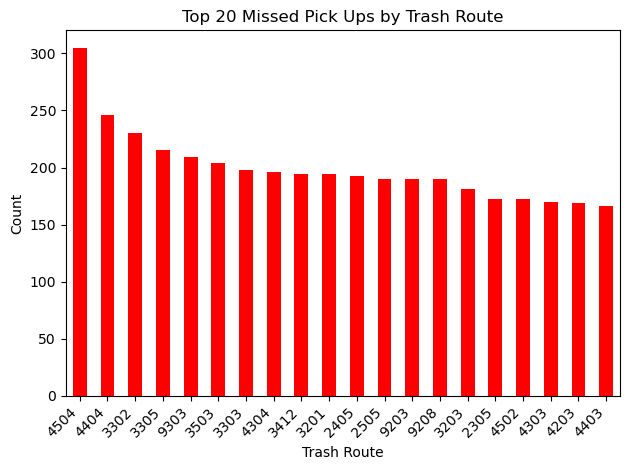

In [189]:
top_20_missed_bar = missed_pu_routes['Trash Route'].value_counts().head(20).plot(kind='bar', color='red')
plt.title('Top 20 Missed Pick Ups by Trash Route')
plt.xlabel('Trash Route')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [191]:
trash_report.head

<bound method NDFrame.head of        Request Number Date Opened                              Request   \
0               25270  2017-11-01                      Trash - Backdoor   
1               25274  2017-11-01  Trash - Curbside/Alley Missed Pickup   
2               25276  2017-11-01  Trash - Curbside/Alley Missed Pickup   
3               25307  2017-11-01  Trash - Curbside/Alley Missed Pickup   
4               25312  2017-11-01  Trash - Curbside/Alley Missed Pickup   
...               ...         ...                                   ...   
20221          267125  2019-11-01  Trash - Curbside/Alley Missed Pickup   
20222          267126  2019-11-01  Trash - Curbside/Alley Missed Pickup   
20223          267130  2019-11-01  Trash - Curbside/Alley Missed Pickup   
20224          267134  2019-11-01  Trash - Curbside/Alley Missed Pickup   
20225          267137  2019-11-01  Trash - Curbside/Alley Missed Pickup   

                                             Description  \
0      ho

In [195]:
trash_report['Date Opened'].dtypes

dtype('<M8[ns]')

In [196]:
alt_1 = trash_report[trash_report['Request '] == 'Trash - Curbside/Alley Missed Pickup']

In [197]:
alt_1

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,address_clean
1,25274,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike
2,25276,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Drive,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr
3,25307,2017-11-01,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd
4,25312,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley Drive,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr
8,25330,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed.,4484 Lavergne Couchville Pike,37013.0,RED RIVER,4210,33.0,1794533.514,618749.3427,4484 Lavergne Couchville Pike
...,...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,2019-11-01,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1781137.263,632448.5511,2731 Murfreesboro Pike
20222,267126,2019-11-01,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1749711.399,669201.6016,1621 Long Ave
20223,267130,2019-11-01,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1770293.388,674936.3038,2943 Windemere Cir
20224,267134,2019-11-01,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1785224.998,627146.4002,3325 Murfreesboro Pike


In [199]:
alt_1 = alt_1.sort_values(['address_clean', 'Date Opened'])

In [200]:
alt_1

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,address_clean
4477,79395,2018-06-29,Trash - Curbside/Alley Missed Pickup,the entire street was missed,1 BELLE FORREST AVE C,37206.0,METRO,9502,7.0,1751942.483,677895.3105,1 Belle Forrest Ave C
4511,79884,2018-07-02,Trash - Curbside/Alley Missed Pickup,Missed entire street- carts are curbside in fr...,10 Belle Forrest Ave,37206.0,METRO,9502,7.0,1751718.498,678077.9341,10 Belle Forrest Ave
10929,155122,2019-03-15,Trash - Curbside/Alley Missed Pickup,MISS,"100 Bluefield Square, Nashville, TN 37214, Uni...",37214.0,RED RIVER,1505,15.0,1770430.599,666861.6014,100 Bluefield Square
2214,52252,2018-03-07,Trash - Curbside/Alley Missed Pickup,Missed- trash,100 Braxton Hill Ct,37204.0,RED RIVER,3302S,25.0,1733780.504,640909.3036,100 Braxton Hill Ct
7727,121431,2018-12-05,Trash - Curbside/Alley Missed Pickup,Missed- trash,100 Brook Hollow Rd,37205.0,RED RIVER,1303,23.0,1708042.849,642454.6429,100 Brook Hollow Rd
...,...,...,...,...,...,...,...,...,...,...,...,...
1346,41604,2018-01-24,Trash - Curbside/Alley Missed Pickup,cart still out,NaN,37218.0,RED RIVER,3203,1.0,1715186.450,682289.9617,NaN
2794,58920,2018-04-06,Trash - Curbside/Alley Missed Pickup,missed- trash,NaN,37206.0,METRO,9503,5.0,1747402.049,674741.0561,NaN
2839,59517,2018-04-10,Trash - Curbside/Alley Missed Pickup,Trash was not pick up last week.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3121,62051,2018-04-22,Trash - Curbside/Alley Missed Pickup,They forgot to pick up trash from apartment co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [215]:
missed_pickups_df['fine_owed'].sum()

np.int64(888400)

CURRENT FINE METHOD TOTAL: 888,400